# Introduction
This notebook's purpose is to explore HelloFresh reddit posts on the r/hellofresh subreddit.
We want to investigate sentiment analysis and 
Try to understand where the common complaints come from.

# Using the official Reddit API
Reddit provides an API to developers. The PRAW python reddit api wrapper library helps follow usage limits and just requires some credentials you can freely request. For more info about PRAW, [read the docs](https://praw.readthedocs.io/en/latest/getting_started/quick_start.html)

In [1]:
# Install PRAW - Python Reddit API Wrapper
!pip install praw -Uqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.0 MB/s eta 0:00:00


In [2]:
# Import needed libraries
import praw
import pandas as pd
import json

# Import secrets
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
RCI = user_secrets.get_secret("REDDIT_CLIENT_ID")
RCS = user_secrets.get_secret("REDDIT_CLIENT_SECRET")
RU = user_secrets.get_secret("REDDIT_USER")

In [3]:
# Init reddit instance
reddit = praw.Reddit(
    client_id=RCI,
    client_secret=RCS,
    user_agent=f"hellofresh_scraper by u/{RU}"
)

In [4]:
# Choose the subreddit
subreddit = reddit.subreddit("hellofresh")

# Fetch a single post to check the api
post = next(subreddit.hot(limit=1))
post_dict = vars(post)

print(pd.DataFrame([post_dict]).columns.tolist())

['comment_limit', 'comment_sort', '_reddit', 'approved_at_utc', 'subreddit', 'selftext', 'author_fullname', 'saved', 'mod_reason_title', 'gilded', 'clicked', 'title', 'link_flair_richtext', 'subreddit_name_prefixed', 'hidden', 'pwls', 'link_flair_css_class', 'downs', 'thumbnail_height', 'top_awarded_type', 'hide_score', 'name', 'quarantine', 'link_flair_text_color', 'upvote_ratio', 'author_flair_background_color', 'subreddit_type', 'ups', 'total_awards_received', 'media_embed', 'thumbnail_width', 'author_flair_template_id', 'is_original_content', 'user_reports', 'secure_media', 'is_reddit_media_domain', 'is_meta', 'category', 'secure_media_embed', 'link_flair_text', 'can_mod_post', 'score', 'approved_by', 'is_created_from_ads_ui', 'author_premium', 'thumbnail', 'edited', 'author_flair_css_class', 'author_flair_richtext', 'gildings', 'content_categories', 'is_self', 'mod_note', 'created', 'link_flair_type', 'wls', 'removed_by_category', 'banned_by', 'author_flair_type', 'domain', 'allow

Definitely a lot of context retrieved for one API pull.  

Great news though - we've connected to reddit via the official api!

The schema/model of these data is available on the docs [submission page](https://praw.readthedocs.io/en/stable/code_overview/models/submission.html)  

Of note is the created_utc field in Unix Time - so we'll definitely want to make that readable.

In [5]:

# Clean the UTC in unix time as a function
def clean_reddit_utc_to_date(df):
    df['created_date'] = pd.to_datetime(df['created_utc'], unit='s').dt.strftime('%Y-%m-%d')

In [6]:
# Choose the subreddit
subreddit = reddit.subreddit("hellofresh")

# Fetch the hot 100 posts in the sub
posts = []
for post in subreddit.hot(limit=1000):  # .new() or .top() etc usage limit 100/min
    posts.append({
        "id": post.id,
        "title": post.title,
        "score": post.score,
        "author": str(post.author),
        "created_utc": post.created_utc,
        "num_comments": post.num_comments,
        "selftext": post.selftext,
        "url": post.url
    })

# Save to CSV
hf_hot_df = pd.DataFrame(posts)
# Clean the df
clean_reddit_utc_to_date(hf_hot_df)
# Save as a CSV
hf_hot_df.to_csv("hellofresh_hot1000.csv", index=False)
# Display the table
display(hf_hot_df.head())

print("Saved to hellofresh_hot1000.csv")

,id,title,score,author,created_utc,num_comments,selftext,url,created_date
0,1mbd4l9,"Share Weekly Trial, Offer, and Free Box Codes ...",2,AutoModerator,1.753700e+09,86,Use this space to share trial and offer codes...,https://www.reddit.com/r/hellofresh/comments/1...,2025-07-28
1,1mfbbzk,My ice packs keep exploding/leaking all over m...,2,theregulardog,1.754090e+09,0,Hello! So I have experienced the problem detai...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01
2,1mfbub4,Improvements ?!?,0,TommyDaComic,1.754092e+09,1,"Got an email that says in about two weeks, exp...",https://www.reddit.com/gallery/1mfbub4,2025-08-01
3,1mf2vlc,Shipping failures - W. NY,1,Seth0067,1.754070e+09,6,Hello Fresh has missed two deliveries in two w...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01
4,1medzbt,Kimchi Grilled Cheese,33,Tfcalex96,1.753997e+09,6,Havent seen a review of this on the sub before...,https://i.redd.it/y9u3a97y1agf1.jpeg,2025-07-31


Saved to hellofresh_hot1000.csv


# Other data sources
r/mealkits is another subreddit with some data that is relevant.  
I've written but commented out the code here for future development work if wanted

In [7]:
# # Choose the subreddit
# subreddit = reddit.subreddit("mealkits")

# # Fetch the hot 100 posts in the sub
# posts = []
# for post in subreddit.hot(limit=1000):  # .new() or .top() etc usage limit 100/min
#     posts.append({
#         "id": post.id,
#         "title": post.title,
#         "score": post.score,
#         "author": str(post.author),
#         "created_utc": post.created_utc,
#         "num_comments": post.num_comments,
#         "selftext": post.selftext,
#         "url": post.url
#     })

# # Save to CSV
# mealkit_hot_df = pd.DataFrame(posts)
# # Clean with function
# clean_reddit_utc_to_date(mealkit_hot_df)
# # Save to CSV
# mealkit_hot_df.to_csv("mealkits_hot100.csv", index=False)
# # print df head
# display(mealkit_hot_df.head())
# print("Saved to mealkits_hot100.csv")
# print(len(mealkit_hot_df))

We could also search r/mealkits for hellofresh

In [8]:
# # Choose the subreddit
# subreddit = reddit.subreddit("mealkits")

# # Fetch the hot 100 posts in the sub
# posts = []
# for post in subreddit.search(query="hellofresh", time_filter="year"):  # .new() or .top() etc usage limit 100/min
#     posts.append({
#         "id": post.id,
#         "title": post.title,
#         "score": post.score,
#         "author": str(post.author),
#         "created_utc": post.created_utc,
#         "num_comments": post.num_comments,
#         "selftext": post.selftext,
#         "url": post.url
#     })

# # Save to CSV
# mealkit_hf_df = pd.DataFrame(posts)
# # Clean with function
# clean_reddit_utc_to_date(mealkit_hf_df)
# # Save to CSV
# mealkit_hf_df.to_csv("mealkits_hellofresh.csv", index=False)
# # print df head
# display(mealkit_hf_df.head())
# print("Saved to mealkits_hellofresh.csv")

If using multiple sources we can concat them easily with pandas

In [9]:
# Combine all 3 of our sources
# df_stacked = pd.concat([hf_hot_df, mealkit_hot_df, mealkit_hf_df])

Now that we have some data to start with, let's try some out of the box sentiment analysis.  

VADER (Valence Aware Dictionary for Sentiment Reasoning) - part of nltk - is good for social media/text data.

nltk (Natural Language Toolkit)

In [10]:
!pip install nltk -Uqq

In [11]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [12]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [13]:
# We're going to do some transformations - so we'll copy the df and use it for sia
# df = df_stacked.copy() # if downloading multiple sources
df = hf_hot_df.copy() # for just r/hellofresh

In [14]:
# test sentiment on title
df["title_compound"] = df["title"].fillna('').apply(lambda x: sia.polarity_scores(x)['compound'])

In [15]:
df[['title','title_compound']]

,title,title_compound
0,"Share Weekly Trial, Offer, and Free Box Codes ...",0.6705
1,My ice packs keep exploding/leaking all over m...,-0.2411
2,Improvements ?!?,0.4501
3,Shipping failures - W. NY,-0.4588
4,Kimchi Grilled Cheese,0.0000
...,...,...
989,Firecracker meatballs w/roasted carrots & jasm...,0.0000
990,Unseasoned chickpea curry?,0.0000
991,Is this really 4 tbsp…. I doubt it. I hate whe...,-0.8261
992,Marry me chicken rigatoni,0.0000


The compound score is a VADER calculation where -1.0 is very negative and +1.0 is very positive

In [16]:
df[['title_pos', 'title_neu', 'title_neg']] = df['title'].fillna('').apply(
    lambda x: pd.Series(sia.polarity_scores(x)[key] for key in ['pos', 'neu', 'neg'])
)

df.head()

,id,title,score,author,created_utc,num_comments,selftext,url,created_date,title_compound,title_pos,title_neu,title_neg
0,1mbd4l9,"Share Weekly Trial, Offer, and Free Box Codes ...",2,AutoModerator,1.753700e+09,86,Use this space to share trial and offer codes...,https://www.reddit.com/r/hellofresh/comments/1...,2025-07-28,0.6705,0.440,0.560,0.000
1,1mfbbzk,My ice packs keep exploding/leaking all over m...,2,theregulardog,1.754090e+09,0,Hello! So I have experienced the problem detai...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.2411,0.000,0.911,0.089
2,1mfbub4,Improvements ?!?,0,TommyDaComic,1.754092e+09,1,"Got an email that says in about two weeks, exp...",https://www.reddit.com/gallery/1mfbub4,2025-08-01,0.4501,0.747,0.253,0.000
3,1mf2vlc,Shipping failures - W. NY,1,Seth0067,1.754070e+09,6,Hello Fresh has missed two deliveries in two w...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.4588,0.000,0.500,0.500
4,1medzbt,Kimchi Grilled Cheese,33,Tfcalex96,1.753997e+09,6,Havent seen a review of this on the sub before...,https://i.redd.it/y9u3a97y1agf1.jpeg,2025-07-31,0.0000,0.000,1.000,0.000


In [17]:
# Sentiment on selftext
df['selftext_compound'] = df['selftext'].fillna('').apply(lambda x: sia.polarity_scores(x)['compound'])

df[['selftext','selftext_compound']]

,selftext,selftext_compound
0,Use this space to share trial and offer codes...,0.2960
1,Hello! So I have experienced the problem detai...,-0.0880
2,"Got an email that says in about two weeks, exp...",0.6617
3,Hello Fresh has missed two deliveries in two w...,0.2144
4,Havent seen a review of this on the sub before...,0.9388
...,...,...
989,Too much ginger in the meatballs for me. Would...,0.5106
990,We're big hello fresh fans here and I don't th...,-0.7506
991,,0.0000
992,I am generally really happy with our HF meals ...,0.6936


In [18]:
df[['selftext_pos', 'selftext_neu', 'selftext_neg']] = df['selftext'].fillna('').apply(
    lambda x: pd.Series(sia.polarity_scores(x)[key] for key in ['pos', 'neu', 'neg'])
)
df.head()

,id,title,score,author,created_utc,num_comments,selftext,url,created_date,title_compound,title_pos,title_neu,title_neg,selftext_compound,selftext_pos,selftext_neu,selftext_neg
0,1mbd4l9,"Share Weekly Trial, Offer, and Free Box Codes ...",2,AutoModerator,1.753700e+09,86,Use this space to share trial and offer codes...,https://www.reddit.com/r/hellofresh/comments/1...,2025-07-28,0.6705,0.440,0.560,0.000,0.2960,0.047,0.953,0.000
1,1mfbbzk,My ice packs keep exploding/leaking all over m...,2,theregulardog,1.754090e+09,0,Hello! So I have experienced the problem detai...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.2411,0.000,0.911,0.089,-0.0880,0.069,0.860,0.071
2,1mfbub4,Improvements ?!?,0,TommyDaComic,1.754092e+09,1,"Got an email that says in about two weeks, exp...",https://www.reddit.com/gallery/1mfbub4,2025-08-01,0.4501,0.747,0.253,0.000,0.6617,0.104,0.896,0.000
3,1mf2vlc,Shipping failures - W. NY,1,Seth0067,1.754070e+09,6,Hello Fresh has missed two deliveries in two w...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.4588,0.000,0.500,0.500,0.2144,0.084,0.831,0.085
4,1medzbt,Kimchi Grilled Cheese,33,Tfcalex96,1.753997e+09,6,Havent seen a review of this on the sub before...,https://i.redd.it/y9u3a97y1agf1.jpeg,2025-07-31,0.0000,0.000,1.000,0.000,0.9388,0.146,0.811,0.043


In [19]:
# Combined average score
df['combined_compound'] = df[['title_compound', 'selftext_compound']].mean(axis=1)
df.head()

,id,title,score,author,created_utc,num_comments,selftext,url,created_date,title_compound,title_pos,title_neu,title_neg,selftext_compound,selftext_pos,selftext_neu,selftext_neg,combined_compound
0,1mbd4l9,"Share Weekly Trial, Offer, and Free Box Codes ...",2,AutoModerator,1.753700e+09,86,Use this space to share trial and offer codes...,https://www.reddit.com/r/hellofresh/comments/1...,2025-07-28,0.6705,0.440,0.560,0.000,0.2960,0.047,0.953,0.000,0.48325
1,1mfbbzk,My ice packs keep exploding/leaking all over m...,2,theregulardog,1.754090e+09,0,Hello! So I have experienced the problem detai...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.2411,0.000,0.911,0.089,-0.0880,0.069,0.860,0.071,-0.16455
2,1mfbub4,Improvements ?!?,0,TommyDaComic,1.754092e+09,1,"Got an email that says in about two weeks, exp...",https://www.reddit.com/gallery/1mfbub4,2025-08-01,0.4501,0.747,0.253,0.000,0.6617,0.104,0.896,0.000,0.55590
3,1mf2vlc,Shipping failures - W. NY,1,Seth0067,1.754070e+09,6,Hello Fresh has missed two deliveries in two w...,https://www.reddit.com/r/hellofresh/comments/1...,2025-08-01,-0.4588,0.000,0.500,0.500,0.2144,0.084,0.831,0.085,-0.12220
4,1medzbt,Kimchi Grilled Cheese,33,Tfcalex96,1.753997e+09,6,Havent seen a review of this on the sub before...,https://i.redd.it/y9u3a97y1agf1.jpeg,2025-07-31,0.0000,0.000,1.000,0.000,0.9388,0.146,0.811,0.043,0.46940


In [20]:
# now let's get a group variable and aggregate
from datetime import datetime

# Round to week
df['created_date'] = pd.to_datetime(df['created_date'])
df['week'] = df['created_date'].dt.to_period("W").dt.start_time

# Group by week: mean and count
weekly_sentiment = df.groupby('week').agg(
    avg_sentiment=('combined_compound', 'mean'),
    post_count=('combined_compound', 'count')
).reset_index()

weekly_sentiment.describe()

,week,avg_sentiment,post_count
count,22,22.000000,22.000000
mean,2025-05-15 12:00:00,0.211155,45.181818
min,2025-03-03 00:00:00,0.138517,32.000000
25%,2025-04-08 18:00:00,0.186350,37.000000
50%,2025-05-15 12:00:00,0.209845,42.000000
75%,2025-06-21 06:00:00,0.231076,54.500000
max,2025-07-28 00:00:00,0.279028,69.000000
std,NaN,0.040284,10.191670


In [21]:
# Filter to start date 
start_date = '2024-01-01'
weekly_sentiment = weekly_sentiment[weekly_sentiment.week >= pd.to_datetime(start_date)]

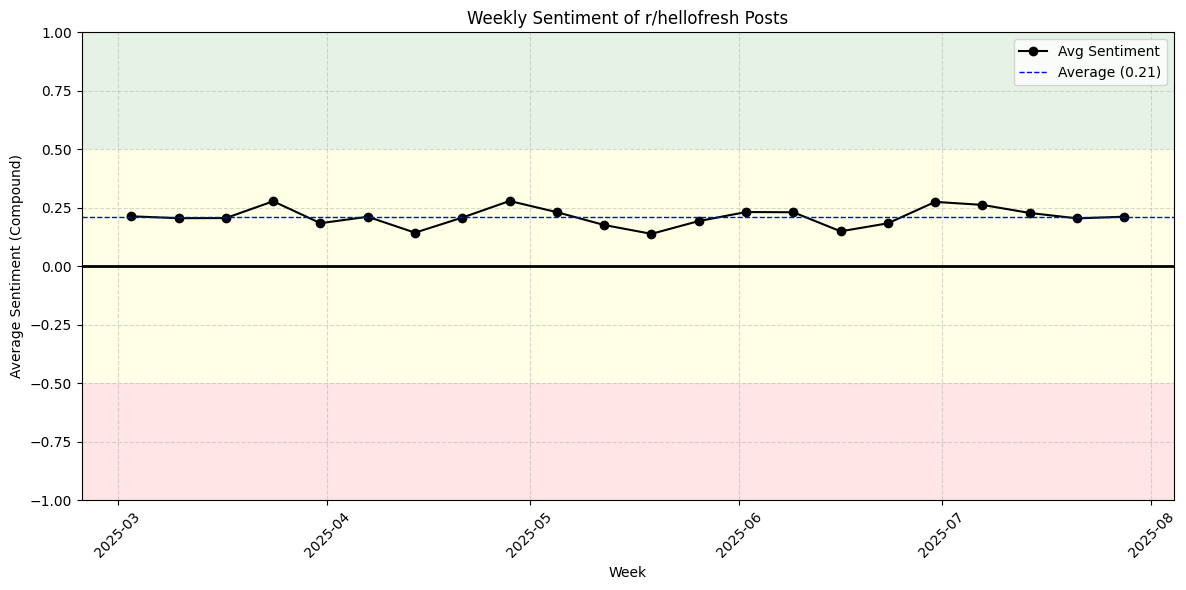

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the sentiment line
ax.plot(weekly_sentiment['week'], weekly_sentiment['avg_sentiment'], marker='o', color='black', label='Avg Sentiment')

# Highlight zones
ax.axhspan(-1, -0.5, facecolor='red', alpha=0.1)
ax.axhspan(-0.5, 0.5, facecolor='yellow', alpha=0.1)
ax.axhspan(0.5, 1, facecolor='green', alpha=0.1)

# Thicker zero line
ax.axhline(0, color='black', linewidth=2)

# Add an average line
avg_sentiment = weekly_sentiment['avg_sentiment'].mean()
ax.axhline(avg_sentiment, color='blue', linestyle='--', linewidth=1, label=f'Average ({avg_sentiment:.2f})')

# Formatting
ax.set_title("Weekly Sentiment of r/hellofresh Posts")
ax.set_xlabel("Week")
ax.set_ylabel("Average Sentiment (Compound)")
ax.set_ylim(-1, 1)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# r/hellofresh hot 1000 posts sentiment is neutral
Averages around 0.21 as of August 1st, 2025

VADER Sentiment analysis is scaled from -1.0 to 1.0 where:
- +1 is the most postive sentiment  
- 0 is neutral  
- -1 is the most negative sentiment

So, the plot >0.5 is postive (green), between -0.5 and +0.5 is netural (yellow) and below -0.5 is negative (red)

# Retrospecitve removal of 0 score
After reviewing boxplots of sentiment averages I noticed several combined compound scores of 0.0. This is unlikely real and more an error on BERT's part - the inability to truly judge with limited information. Let's plot the average again but remove the zeros first


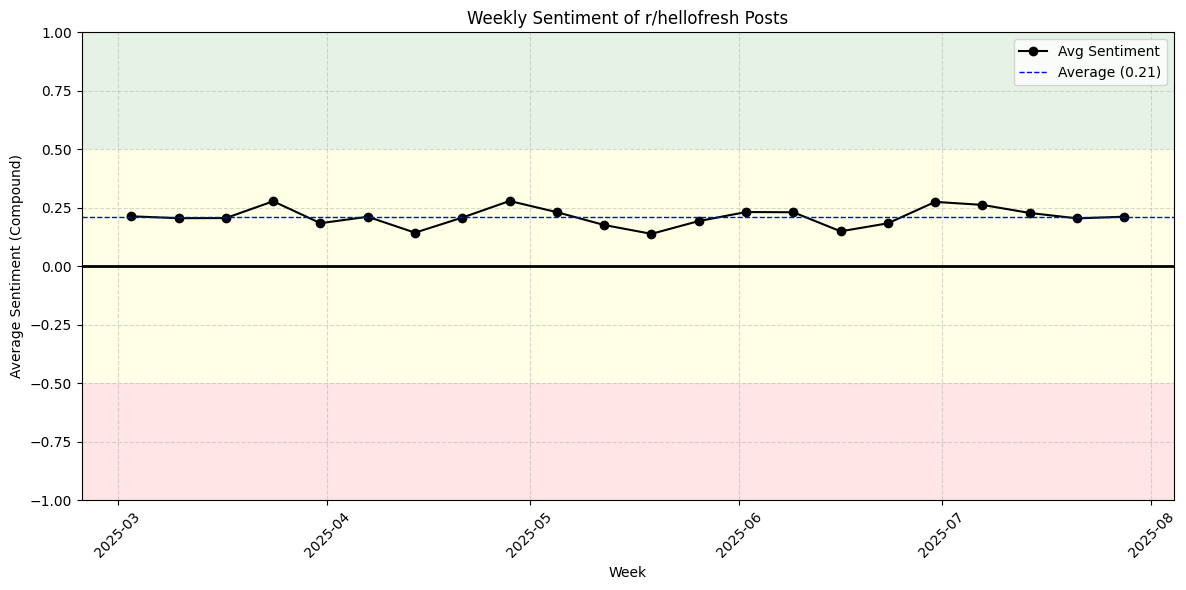

In [23]:
no_zeros = weekly_sentiment[weekly_sentiment.avg_sentiment.ne(0)]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the sentiment line
ax.plot(no_zeros['week'], no_zeros['avg_sentiment'], marker='o', color='black', label='Avg Sentiment')

# Highlight zones
ax.axhspan(-1, -0.5, facecolor='red', alpha=0.1)
ax.axhspan(-0.5, 0.5, facecolor='yellow', alpha=0.1)
ax.axhspan(0.5, 1, facecolor='green', alpha=0.1)

# Thicker zero line
ax.axhline(0, color='black', linewidth=2)

# Add an average line
avg_sentiment = no_zeros['avg_sentiment'].mean()
ax.axhline(avg_sentiment, color='blue', linestyle='--', linewidth=1, label=f'Average ({avg_sentiment:.2f})')

# Formatting
ax.set_title("Weekly Sentiment of r/hellofresh Posts")
ax.set_xlabel("Week")
ax.set_ylabel("Average Sentiment (Compound)")
ax.set_ylim(-1, 1)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Digging into problems
Let's find out why there are negative comments and what those are about

In [24]:
# First we'll get the minimum sentiment and maximum sentiment by week
# Group by week: mean and count
range_sentiment = df.groupby('week').agg(
    min_sentiment=('combined_compound', 'min'),
    max_sentiment=('combined_compound', 'max'),
    post_count=('combined_compound', 'count')
).reset_index()

range_sentiment.head(1)

,week,min_sentiment,max_sentiment,post_count
0,2025-03-03,-0.54735,0.7,39


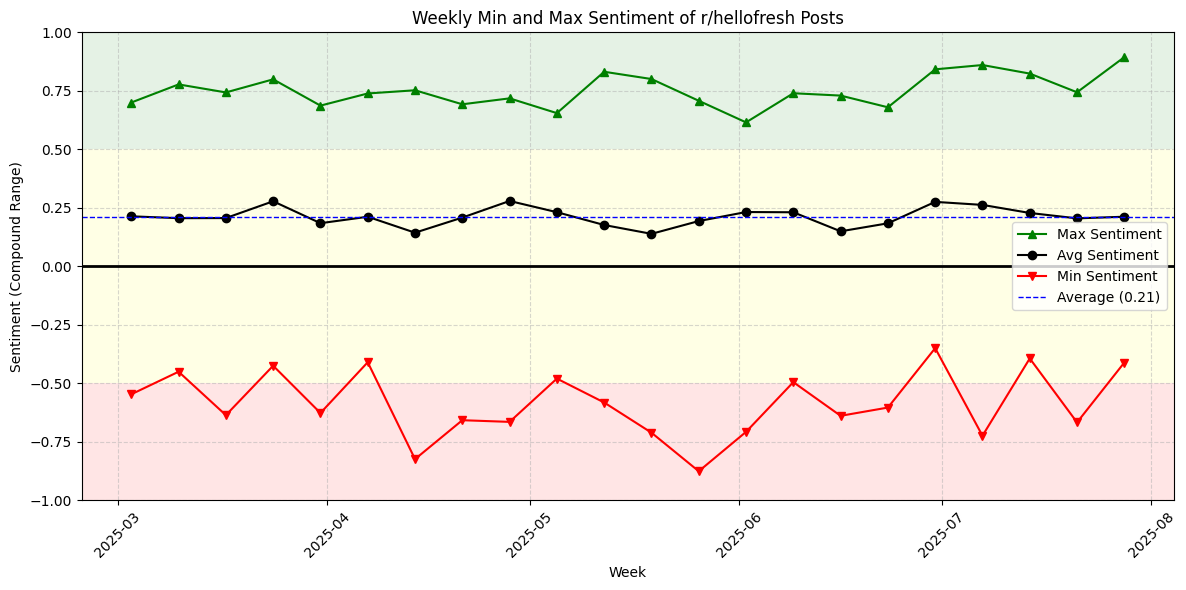

In [25]:
# Filter to start date 
start_date = '2024-01-01'
range_sentiment = range_sentiment[range_sentiment.week >= pd.to_datetime(start_date)]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the sentiment line
ax.plot(range_sentiment['week'], range_sentiment['max_sentiment'], marker='^', color='green', label='Max Sentiment')
ax.plot(weekly_sentiment['week'], weekly_sentiment['avg_sentiment'], marker='o', color='black', label='Avg Sentiment')
ax.plot(range_sentiment['week'], range_sentiment['min_sentiment'], marker='v', color='red', label='Min Sentiment')


# Highlight zones
ax.axhspan(-1, -0.5, facecolor='red', alpha=0.1)
ax.axhspan(-0.5, 0.5, facecolor='yellow', alpha=0.1)
ax.axhspan(0.5, 1, facecolor='green', alpha=0.1)

# Thicker zero line
ax.axhline(0, color='black', linewidth=2)

# Add an average line
avg_sentiment = weekly_sentiment['avg_sentiment'].mean()
ax.axhline(avg_sentiment, color='blue', linestyle='--', linewidth=1, label=f'Average ({avg_sentiment:.2f})')

# Formatting
ax.set_title("Weekly Min and Max Sentiment of r/hellofresh Posts")
ax.set_xlabel("Week")
ax.set_ylabel("Sentiment (Compound Range)")
ax.set_ylim(-1, 1)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Aside about VADER
Vader is a rules based, lexion/dictionary, and heuristic model. It was designed for short texts like tweets, reddit, and reviews.

It uses a prebuilt lexicon: a dictionary of works with sentiment inensity scores (pos,neu,neg).  
It applies rules to handle..
- punctuation (!!! increases intensity)
- capitalization ( ALL CAPS boosts score)
- degree modifier (very good is stronger than good)
- negation (not good flips sentiment)

Scores from words and modifiers are combined in a compound score between -1 and +1.
It does miss sarcasm or complex language.

# What is going wrong when things go wrong?
For the comments that are negative ( below -0.5 ) what are the issues?

In [26]:
# First let's filter to just the negative compound reviews
neg_df = df[df['combined_compound'] <= -0.5].copy()
neg_df.head()

,id,title,score,author,created_utc,num_comments,selftext,url,created_date,title_compound,title_pos,title_neu,title_neg,selftext_compound,selftext_pos,selftext_neu,selftext_neg,combined_compound,week
54,1m7i60x,Any reason why there's suddenly problems?,0,cohenjsam,1.753298e+09,6,"I've been with them for a little while now, pr...",https://www.reddit.com/r/hellofresh/comments/1...,2025-07-23,-0.4019,0.0,0.649,0.351,-0.9332,0.066,0.766,0.168,-0.66755,2025-07-21
125,1lwuhsr,"HelloFresh heavy discount to come, they are st...",0,eatwell_relaxwell62,1.752198e+09,9,"HF has closed multiple sites, rrhey plan to cl...",https://www.reddit.com/r/hellofresh/comments/1...,2025-07-11,-0.4215,0.0,0.714,0.286,-0.8398,0.042,0.822,0.136,-0.63065,2025-07-07
132,1lvwlwj,The Packaging is terrible,0,dangforgotmyaccount,1.752101e+09,8,My family started using HF a few weeks ago to ...,https://www.reddit.com/r/hellofresh/comments/1...,2025-07-09,-0.4767,0.0,0.492,0.508,-0.9723,0.057,0.816,0.127,-0.72450,2025-07-07
194,1lnsn61,Not happy,25,Old-Description7290,1.751239e+09,25,I know a lot of you have had problems with pro...,https://www.reddit.com/r/hellofresh/comments/1...,2025-06-29,-0.4585,0.0,0.250,0.750,-0.7169,0.127,0.694,0.179,-0.58770,2025-06-23
218,1lkioaf,Bad experience,19,Waisttallrhinos,1.750888e+09,30,My first box showed up last week barely chille...,https://i.redd.it/6xr5a9vp959f1.jpeg,2025-06-25,-0.5423,0.0,0.222,0.778,-0.6660,0.133,0.707,0.161,-0.60415,2025-06-23


In [27]:
# Text Preprocessing to find word frequency
import re
from sklearn.feature_extraction.text import CountVectorizer

# simple text clean
neg_df['cleaned'] = neg_df['selftext'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)

# Token frequency
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(neg_df['cleaned'])
word_freq = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)

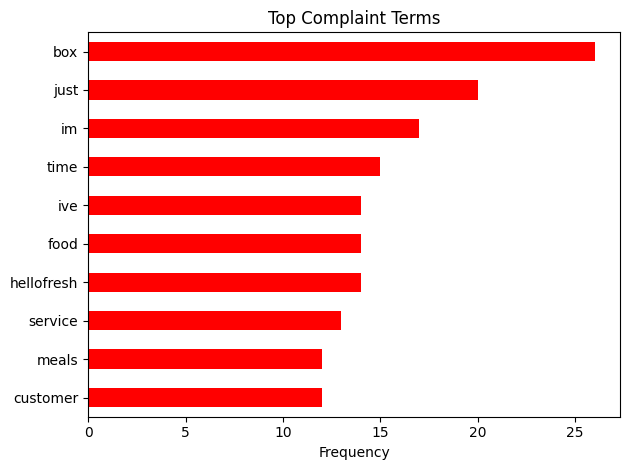

In [28]:

word_freq.head(10).plot(kind='barh', title='Top Complaint Terms', color='red')
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

# Word frequency
So this is just frequency of words in bad reviews.  
A few things are worth referencing:
- box (something about the whole box - maybe obvious)
- time (time to prep meals or time for delivery?)
- food (maybe food quality or quantity)
- service (maybe customer service)
- meals (recipe complaint?)
- customer (maybe customer service)

Let's try bert topic library to do some heavy lifting.

In [29]:
!pip install bertopic[all] sentence-transformers -Uqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.5 MB/s eta 0:00:00


In [30]:
# Ensure negative reviews are a list of strings for bert
docs = neg_df['selftext'].astype(str).tolist()

BERT via Sentence transformer will
- Reduce dimensionality (UMAP)
- Cluster (HDBSCAN)
- Extract keywords by topic

It does employ a transformer - so there is reason to be cautious about running out of CPU or RAM

In [31]:
# Create and fit a bert model
from bertopic import BERTopic

topic_model = BERTopic(language='english', verbose=True)
topics, probs = topic_model.fit_transform(docs)

2025-08-02 01:28:21.753344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754098101.999930      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754098102.069452      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-02 01:29:06,662 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-02 01:29:17,816 - BERTopic - Embedding - Completed ✓
2025-08-02 01:29:17,817 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-02 01:29:27,220 - BERTopic - Dimensionality - Completed ✓
2025-08-02 01:29:27,221 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-02 01:29:27,231 - BERTopic - Cluster - Completed ✓
2025-08-02 01:29:27,238 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-02 01:29:27,267 - BERTopic - Representation - Completed ✓


In [32]:
# View topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_the_and_to_it,"[the, and, to, it, my, was, for, they, of, in]",[I used Hello Fresh for around 5 months and di...


A classic garbage topic - we need to add stop words to improve this.

In [33]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english')) | {"im", "ive", "dont", "youre", "also", "get", "got", "just", "really", "like"}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation/numbers
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

cleaned_docs = [clean_text(doc) for doc in docs]

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
cleaned_docs[:2]

['little probably years cancelled today rd missed delivery weeks stuff happens addition one ones wrong order able refund part ones missed say today delivered doordash delivered wrong place neither dd hf could help find delivered said contact anyone know suddenly problems chance leadership new process implemented something curious anything stuff',
 'hf closed multiple sites rrhey plan close illinois site soon indeed distribution centers west coast whole southeast promised investors would rather reduce revenue preserving margins unfortunately doesnt work start discount especially april aug volume lowest cancel friday wait one month try pressure giving discount due sluggish demand food suppliers stayed site longer veggiemeat quality come']

You can see the corpus is a bit more broken now but at least there are less filler words

In [35]:
# re run the model
topic_model = BERTopic(language="english", verbose=True)
topics, probs = topic_model.fit_transform(cleaned_docs)

2025-08-02 01:29:27,936 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-02 01:29:30,365 - BERTopic - Embedding - Completed ✓
2025-08-02 01:29:30,366 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-02 01:29:30,422 - BERTopic - Dimensionality - Completed ✓
2025-08-02 01:29:30,423 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-02 01:29:30,430 - BERTopic - Cluster - Completed ✓
2025-08-02 01:29:30,433 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-02 01:29:30,448 - BERTopic - Representation - Completed ✓


In [36]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_box_time_food_hellofresh,"[box, time, food, hellofresh, service, even, m...",[used hello fresh around months enjoy service ...


The -1 index topic is BERT saying it couldn't find any groupings in the texts. That may be because at the bottom of the reviews there is just one-off complaints. Let's explore the weekly dataset a little more to understand where the distribution of reviews lies.

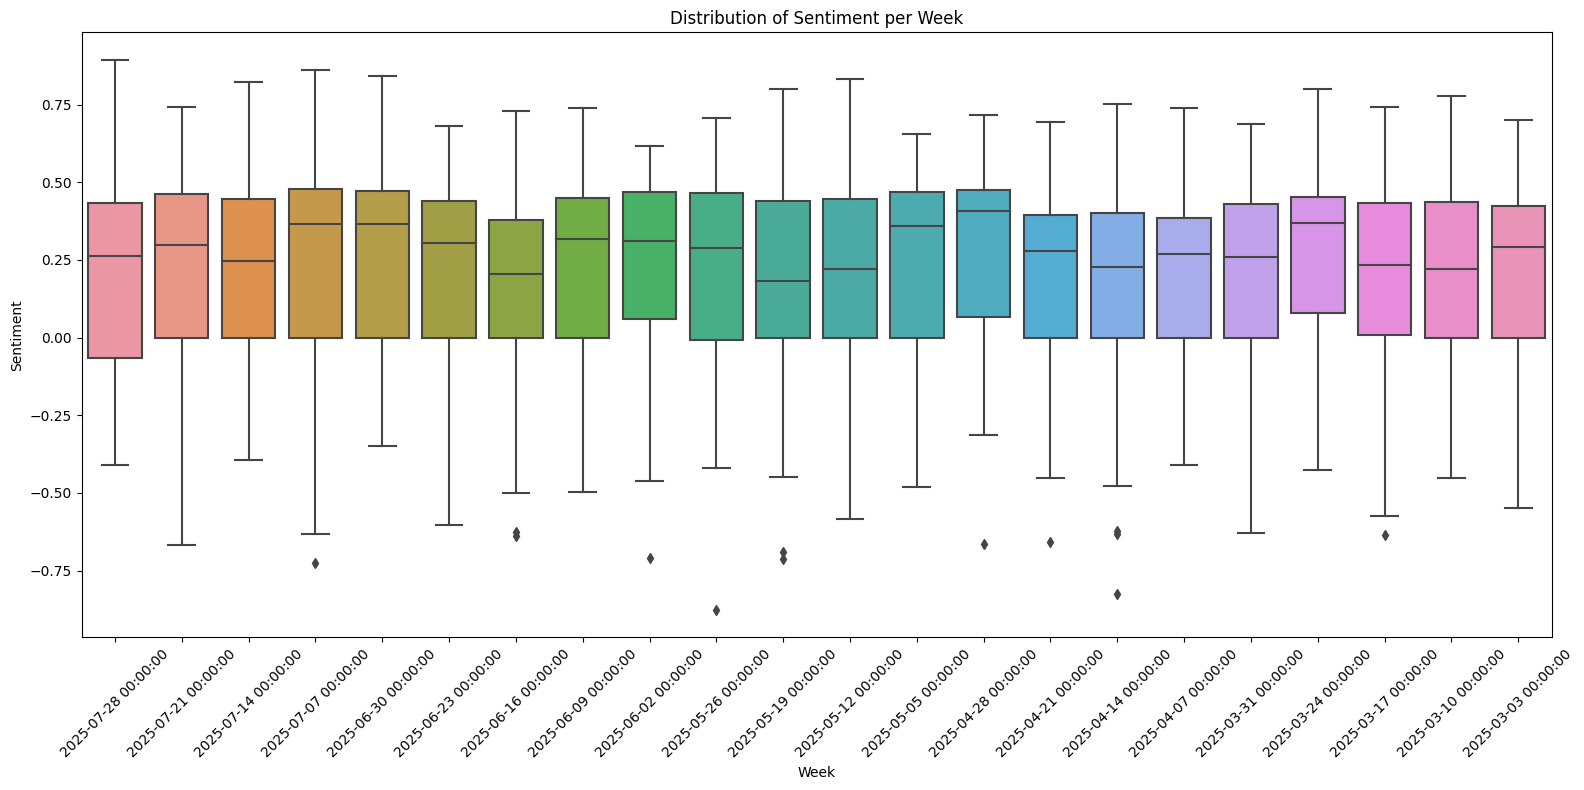

In [37]:
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='week', y='combined_compound')
plt.title("Distribution of Sentiment per Week")
plt.xlabel("Week")
plt.ylabel("Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

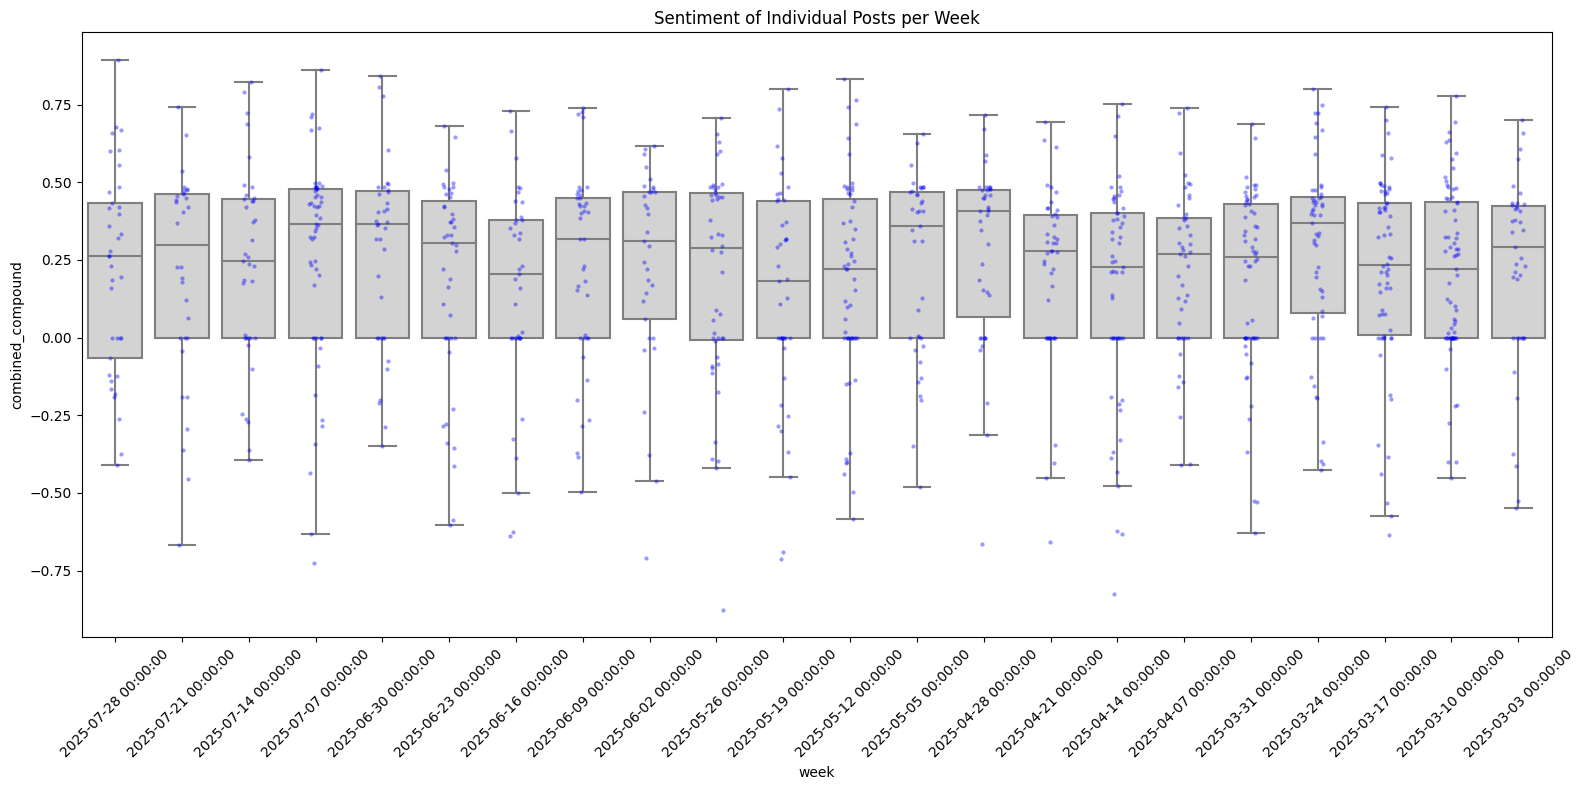

In [38]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='week', y='combined_compound', color='lightgray', fliersize=0)
sns.stripplot(data=df, x='week', y='combined_compound', color='blue', size=3, jitter=True, alpha=0.4)
plt.title("Sentiment of Individual Posts per Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

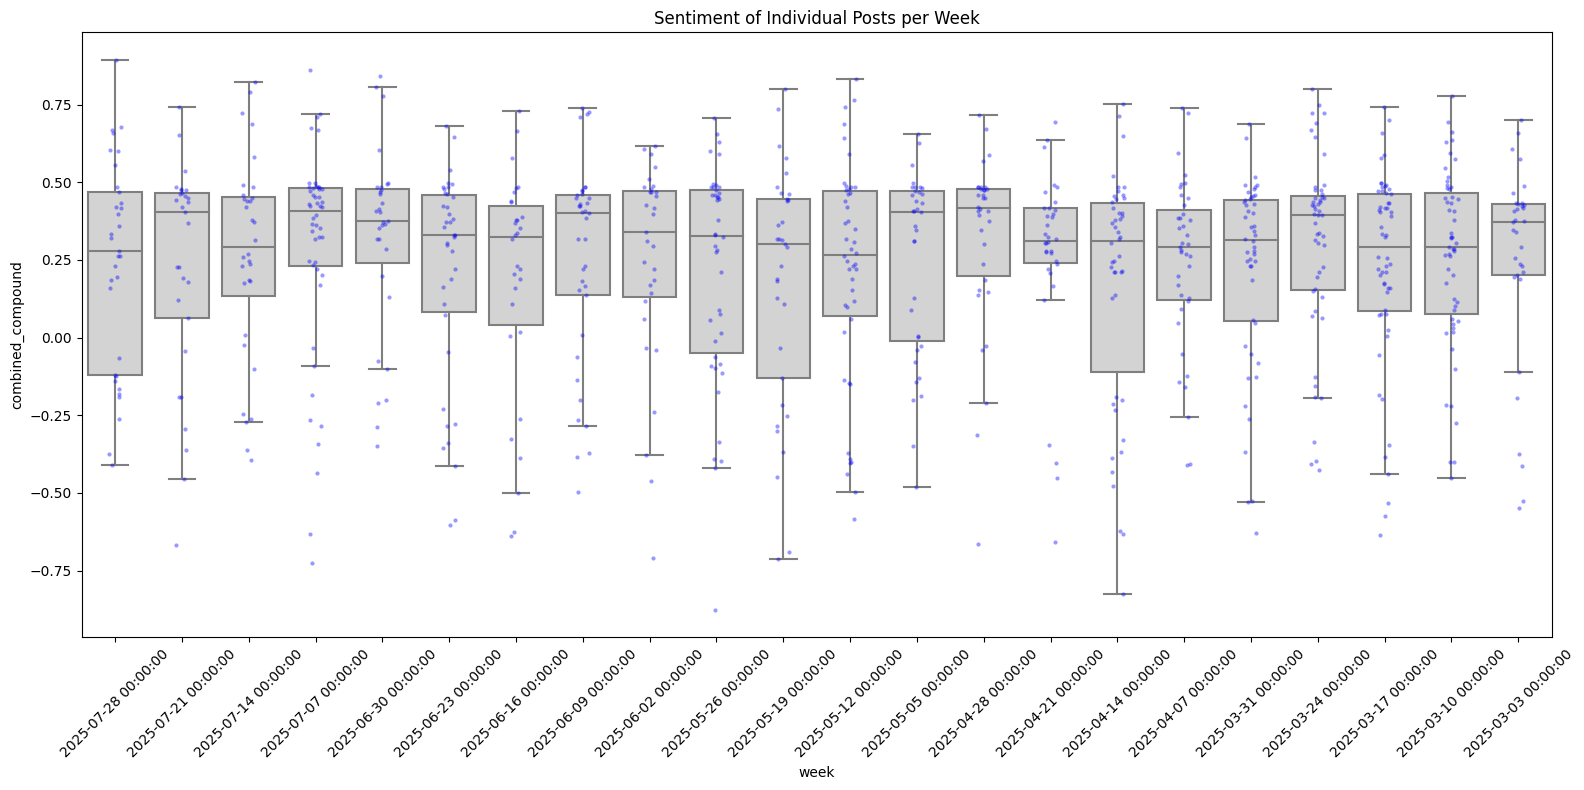

In [39]:
df_no_zero = df[df.combined_compound.ne(0)].copy()
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_no_zero, x='week', y='combined_compound', color='lightgray', fliersize=0)
sns.stripplot(data=df_no_zero, x='week', y='combined_compound', color='blue', size=3, jitter=True, alpha=0.4)
plt.title("Sentiment of Individual Posts per Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

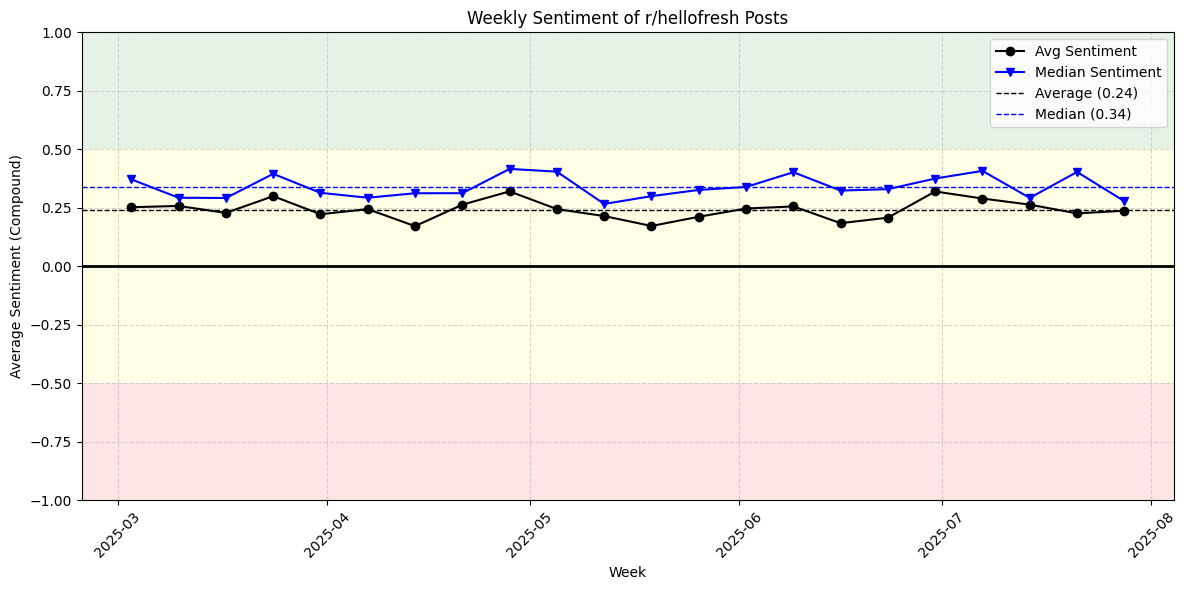

In [40]:
# Group by week: mean and count
nz_weekly_sentiment = df_no_zero.groupby('week').agg(
    avg_sentiment=('combined_compound', 'mean'),
    med_sentiment=('combined_compound', 'median'),
    post_count=('combined_compound', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the sentiment line
ax.plot(nz_weekly_sentiment['week'], nz_weekly_sentiment['avg_sentiment'], marker='o', color='black', label='Avg Sentiment')
ax.plot(nz_weekly_sentiment['week'], nz_weekly_sentiment['med_sentiment'], marker='v', color='blue', label='Median Sentiment')

# Highlight zones
ax.axhspan(-1, -0.5, facecolor='red', alpha=0.1)
ax.axhspan(-0.5, 0.5, facecolor='yellow', alpha=0.1)
ax.axhspan(0.5, 1, facecolor='green', alpha=0.1)

# Thicker zero line
ax.axhline(0, color='black', linewidth=2)

# Add an average line
avg_sentiment = nz_weekly_sentiment['avg_sentiment'].mean()
med_sentiment = nz_weekly_sentiment['med_sentiment'].mean()
ax.axhline(avg_sentiment, color='black', linestyle='--', linewidth=1, label=f'Average ({avg_sentiment:.2f})')
ax.axhline(med_sentiment, color='blue', linestyle='--', linewidth=1, label=f'Median ({med_sentiment:.2f})')

# Formatting
ax.set_title("Weekly Sentiment of r/hellofresh Posts")
ax.set_xlabel("Week")
ax.set_ylabel("Average Sentiment (Compound)")
ax.set_ylim(-1, 1)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The median might be a better estimator for the central composite since several of the boxplots have long negative tails - evaluated very negative.

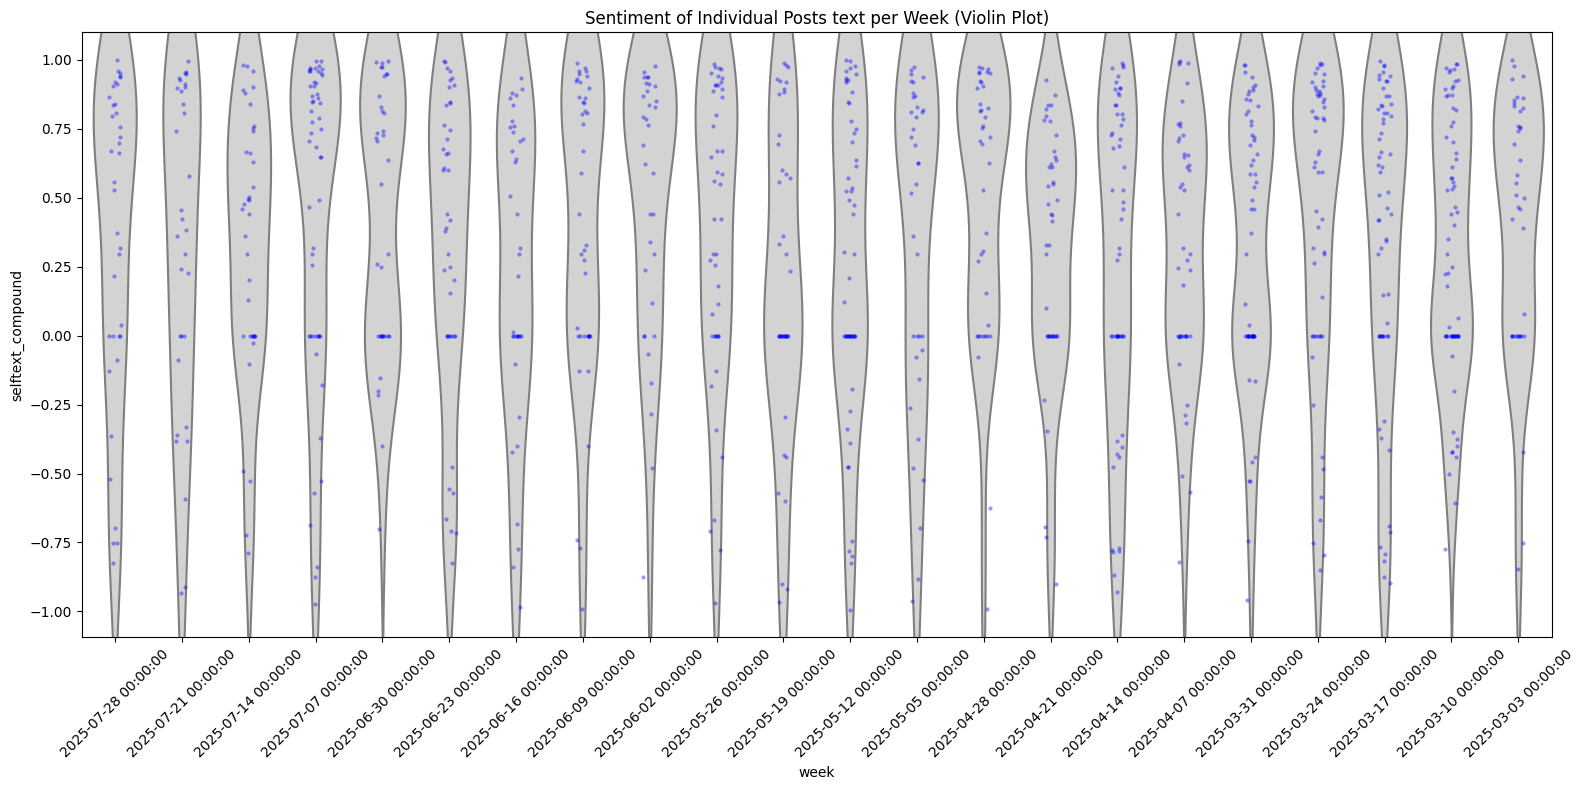

In [41]:
import seaborn as sns

plt.figure(figsize=(16, 8))

# Violin plot instead of boxplot
sns.violinplot(
    data=df,
    x='week',
    y='selftext_compound',
    inner=None,        # Don't show mini-boxplot inside violins
    color='lightgray'
)

# Overlay individual data points
sns.stripplot(
    data=df,
    x='week',
    y='selftext_compound',
    color='blue',
    size=3,
    jitter=True,
    alpha=0.4
)

plt.title("Sentiment of Individual Posts text per Week (Violin Plot)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revising the split
Ah, ok now I see what's going on - the comments that are < -0.5 are really far on the tail of the distribution. Maybe we should try a larger split at anything below 0.

In [42]:
new_neg_df = df[df['combined_compound'] <= 0].copy()
len(new_neg_df)

312

In [43]:
# Ensure negative reviews are a list of strings for bert
neg_docs = new_neg_df['selftext'].astype(str).tolist()

cleaned_neg_docs = [clean_text(doc) for doc in neg_docs]

# re re run the model
topic_model = BERTopic(language="english", verbose=True)
topics, probs = topic_model.fit_transform(cleaned_neg_docs)

2025-08-02 01:29:35,484 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

2025-08-02 01:29:40,251 - BERTopic - Embedding - Completed ✓
2025-08-02 01:29:40,252 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-02 01:29:40,944 - BERTopic - Dimensionality - Completed ✓
2025-08-02 01:29:40,945 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-02 01:29:40,959 - BERTopic - Cluster - Completed ✓
2025-08-02 01:29:40,964 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-02 01:29:40,984 - BERTopic - Representation - Completed ✓


In [44]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,223,0_box_week_anyone_meals,"[box, week, anyone, meals, hellofresh, time, c...",[wife recently gave birth chaos adjusting life...
1,1,89,1_gotta_cry_ontario_hey,"[gotta, cry, ontario, hey, everyone, canada, y...","[gotta try, hey everyone, ontario canada]"


Still only two topic groups... let's just understand the full ds topics

In [45]:
# Ensure negative reviews are a list of strings for bert
all_docs = df['selftext'].astype(str).tolist()

all_docs_cleaned = [clean_text(doc) for doc in all_docs]

# re re run the model
topic_model = BERTopic(language="english", verbose=True)
topics, probs = topic_model.fit_transform(all_docs_cleaned)

2025-08-02 01:29:41,462 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-08-02 01:29:52,564 - BERTopic - Embedding - Completed ✓
2025-08-02 01:29:52,565 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-02 01:29:54,739 - BERTopic - Dimensionality - Completed ✓
2025-08-02 01:29:54,740 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-02 01:29:54,786 - BERTopic - Cluster - Completed ✓
2025-08-02 01:29:54,790 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-02 01:29:54,834 - BERTopic - Representation - Completed ✓


In [46]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,846,0_meals_one_good_meal,"[meals, one, good, meal, box, chicken, would, ...",[benefits meal service significant time mental...
1,1,127,1_supe_cry_yum_means,"[supe, cry, yum, means, hey, everyone, still, ...","[cry, hey everyone, anyone know means]"
2,2,21,2_week_downvoting_contest_refresh,"[week, downvoting, contest, refresh, trolls, b...",[use space share trial offer codes taken refre...


In [47]:
topic_model.visualize_barchart()